# ARIMA Baseline - Walmart Weekly Sales

Non-seasonal ARIMA, fit per Store-Dept series, on a small representative
sample. Goal: get a real, honestly-measured baseline number before moving to
SARIMA (which adds the yearly seasonal component ARIMA can't see).

Design choices for this notebook (deliberately kept simple):
- ~18 series, stratified by sales volume (low / medium / high), not the full
  ~3,331 series -- fast enough to run comfortably on a MacBook, still gives a
  real read on ARIMA's behavior across different series types.
- Order selection via a small AIC grid search over statsmodels.tsa.arima.ARIMA
  instead of pmdarima.auto_arima -- avoids pmdarima's C/Cython build step,
  which is often flaky on Apple Silicon, and is easy to reason about.
- No seasonal terms -- that's what turns this into SARIMA next notebook.
- Reuses splits.py (chronological holdout + expanding-window CV) and
  experiments.py (WMAE weights, result-row schema, run naming) so results
  slot into the same tracking setup your other models will use.

Before running: the import cell below assumes your package is importable
as `src` (i.e. `from src.data import ...`). If your package folder has a
different name, just edit those import lines.



In [1]:
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make the project root importable when running the notebook from notebooks/
project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import mlflow

# If your package isn't named "src", change the imports below.
from src.walmart_forecasting.data import load_processed_data
from src.walmart_forecasting.paths import TABLES_DIR
from src.walmart_forecasting.validation import chronological_holdout, expanding_window_splits
from src.walmart_forecasting.experiment import (
    HOLIDAY_WEIGHT,
    NON_HOLIDAY_WEIGHT,
    CV_FOLDS,
    CV_VALIDATION_WEEKS,
    FINAL_HOLDOUT_WEEKS,
    DEFAULT_RANDOM_SEED,
    build_common_parameters,
    build_result_row,
    save_architecture_result,
    make_run_name,
)
from src.walmart_forecasting.tracking import mlflow_run

# Rename to match whatever experiment name you use in DagsHub/MLflow.
EXPERIMENT_NAME = "walmart-sales-forecasting"

np.random.seed(DEFAULT_RANDOM_SEED)
print("Setup complete.")


Setup complete.


## 1. Load processed data

Using the already-merged, already-validated parquet files from `data/processed`
(built by `save_merged_data` in your EDA notebook) rather than re-reading the
raw CSVs.

In [2]:
processed = load_processed_data()
merged_train = processed.train.copy()
merged_test = processed.test.copy()

merged_train["Date"] = pd.to_datetime(merged_train["Date"])
merged_train = merged_train.sort_values(["Store", "Dept", "Date"]).reset_index(drop=True)

print(f"Train rows: {len(merged_train):,}")
print(f"Unique Store-Dept series: {merged_train.groupby(['Store', 'Dept']).ngroups:,}")
merged_train.head()

Train rows: 421,570
Unique Store-Dept series: 3,331


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


## 2. Build a clean weekly series per (Store, Dept)

ARIMA needs a regularly-spaced time index. Walmart data is weekly on Fridays,
so we reindex each series to a strict `W-FRI` frequency and interpolate any
gaps. Series with too many gaps get skipped rather than aggressively filled.

In [3]:
MAX_ALLOWED_MISSING_WEEKS = 5  # skip a series if more weeks than this are missing

def build_weekly_series(dataframe, store, dept, date_col="Date", value_col="Weekly_Sales"):
    subset = (
        dataframe[(dataframe["Store"] == store) & (dataframe["Dept"] == dept)]
        .sort_values(date_col)
        .set_index(date_col)
        .asfreq("W-FRI")
    )

    n_missing = int(subset[value_col].isna().sum())

    if n_missing > 0:
        subset[value_col] = subset[value_col].interpolate(limit_direction="both")
        if "IsHoliday" in subset.columns:
            subset["IsHoliday"] = subset["IsHoliday"].fillna(False)

    subset["Store"] = store
    subset["Dept"] = dept

    return subset.reset_index(), n_missing


## 3. Select a representative sample of series

Stratify by total sales volume (low / medium / high tercile) and sample
evenly across tiers, restricted to series with (near) complete history so the
CV/holdout splits behave well. Fixed random seed for reproducibility.

In [4]:
N_PER_TIER = 100

series_summary = (
    merged_train.groupby(["Store", "Dept"])
    .agg(total_sales=("Weekly_Sales", "sum"), n_weeks=("Date", "nunique"))
    .reset_index()
)

max_weeks = series_summary["n_weeks"].max()
complete_series = series_summary[series_summary["n_weeks"] >= max_weeks - MAX_ALLOWED_MISSING_WEEKS].copy()

complete_series["volume_tier"] = pd.qcut(
    complete_series["total_sales"], q=3, labels=["low", "medium", "high"]
)

selected_parts = []
for tier in complete_series["volume_tier"].cat.categories:
    tier_df = complete_series[complete_series["volume_tier"] == tier]
    n = min(N_PER_TIER, len(tier_df))
    selected_parts.append(tier_df.sample(n=n, random_state=DEFAULT_RANDOM_SEED))

selected = pd.concat(selected_parts).reset_index(drop=True)

selected_keys = list(zip(selected["Store"], selected["Dept"]))
print(f"Selected {len(selected_keys)} series across volume tiers:")
selected[["Store", "Dept", "total_sales", "n_weeks", "volume_tier"]]


Selected 300 series across volume tiers:


,Store,Dept,total_sales,n_weeks,volume_tier
0,44,16,121040.01,143,low
1,23,36,532334.82,143,low
2,17,28,184603.79,143,low
3,37,67,343604.26,143,low
4,40,26,617538.54,143,low
...,...,...,...,...,...
295,27,16,3538093.49,143,high
296,40,72,5640357.95,143,high
297,4,13,9952291.97,143,high
298,13,46,5923444.75,143,high


## 4. Weighted MAE

Reusing the competition's official weighting from `experiments.py`
(`HOLIDAY_WEIGHT` = 5, `NON_HOLIDAY_WEIGHT` = 1) so numbers here are directly
comparable to whatever the tree models produce later.

In [5]:
def weighted_mae(actual, forecast, is_holiday):
    actual = np.asarray(actual, dtype=float)
    forecast = np.asarray(forecast, dtype=float)
    weights = np.where(np.asarray(is_holiday, dtype=bool), HOLIDAY_WEIGHT, NON_HOLIDAY_WEIGHT)
    return float(np.average(np.abs(actual - forecast), weights=weights))

## 5. Order selection — small AIC grid search

A lightweight stand-in for `auto_arima`: fit a handful of (p, d, q)
combinations and keep whichever has the lowest AIC. Grid is kept small on
purpose (18 combinations) to stay fast across ~18 series x 4 fits each.


In [6]:
ORDER_GRID = [
    (p, d, q)
    for p in range(3)
    for d in range(2)
    for q in range(3)
]


def best_arima_order(train_values, orders=ORDER_GRID):
    best_order, best_aic, best_model = None, np.inf, None

    for order in orders:
        try:
            fitted = ARIMA(
                train_values,
                order=order,
                enforce_stationarity=False,
                enforce_invertibility=False,
            ).fit()
        except Exception:
            continue

        if fitted.aic < best_aic:
            best_order, best_aic, best_model = order, fitted.aic, fitted

    return best_order, best_aic, best_model

## 6. Evaluate each series: 3-fold expanding CV + final holdout

For every selected series:
1. Split off the final `FINAL_HOLDOUT_WEEKS` (39 weeks) as a holdout, matching
   `experiments.py`'s `VALIDATION_ID`.
2. Run 3-fold expanding-window CV on what's left (`CV_FOLDS`, `CV_VALIDATION_WEEKS`).
3. Refit on the full pre-holdout training data and forecast the holdout.

Series that don't have enough history for the split are skipped and reported.

In [7]:
per_series_rows = []
example_forecasts = {}  # (store, dept) -> arrays for plotting later

total_fit_seconds = 0.0
total_predict_seconds = 0.0

for store, dept in selected_keys:
    series_df, n_missing = build_weekly_series(merged_train, store, dept)

    if n_missing > MAX_ALLOWED_MISSING_WEEKS:
        print(f"Skipping Store {store} Dept {dept}: {n_missing} missing weeks (too many)")
        continue

    try:
        holdout_split = chronological_holdout(series_df, validation_weeks=FINAL_HOLDOUT_WEEKS)
    except ValueError as exc:
        print(f"Skipping Store {store} Dept {dept}: {exc}")
        continue

    try:
        cv_splits = expanding_window_splits(
            holdout_split.train, n_splits=CV_FOLDS, validation_weeks=CV_VALIDATION_WEEKS
        )
    except ValueError as exc:
        print(f"Skipping CV for Store {store} Dept {dept}: {exc}")
        continue

    cv_wmaes = []
    for fold in cv_splits:
        fit_start = time.perf_counter()
        order, aic, model = best_arima_order(fold.train["Weekly_Sales"].values)
        total_fit_seconds += time.perf_counter() - fit_start

        if model is None:
            continue

        predict_start = time.perf_counter()
        forecast = model.forecast(steps=len(fold.validation))
        total_predict_seconds += time.perf_counter() - predict_start

        cv_wmaes.append(
            weighted_mae(fold.validation["Weekly_Sales"].values, forecast, fold.validation["IsHoliday"].values)
        )

    if not cv_wmaes:
        print(f"Skipping Store {store} Dept {dept}: no CV fold produced a valid ARIMA fit")
        continue

    fit_start = time.perf_counter()
    order, aic, model = best_arima_order(holdout_split.train["Weekly_Sales"].values)
    total_fit_seconds += time.perf_counter() - fit_start

    if model is None:
        print(f"Skipping Store {store} Dept {dept}: ARIMA failed to converge for the final holdout fit")
        continue

    predict_start = time.perf_counter()
    forecast = model.forecast(steps=len(holdout_split.validation))
    total_predict_seconds += time.perf_counter() - predict_start

    holdout_actual = holdout_split.validation["Weekly_Sales"].values
    holdout_is_holiday = holdout_split.validation["IsHoliday"].values

    holdout_wmae = weighted_mae(holdout_actual, forecast, holdout_is_holiday)
    holdout_mae = float(np.mean(np.abs(holdout_actual - forecast)))
    holdout_rmse = float(np.sqrt(np.mean((holdout_actual - forecast) ** 2)))

    per_series_rows.append({
        "Store": store,
        "Dept": dept,
        "order": order,
        "aic": aic,
        "cv_wmae_mean": float(np.mean(cv_wmaes)),
        "cv_wmae_std": float(np.std(cv_wmaes)),
        "holdout_wmae": holdout_wmae,
        "holdout_mae": holdout_mae,
        "holdout_rmse": holdout_rmse,
        "n_missing_weeks": n_missing,
    })

    example_forecasts[(store, dept)] = {
        "train_dates": holdout_split.train["Date"].values[-26:],
        "train_actual": holdout_split.train["Weekly_Sales"].values[-26:],
        "dates": holdout_split.validation["Date"].values,
        "actual": holdout_actual,
        "forecast": forecast,
    }

    print(f"Store {store} Dept {dept}: order={order}, holdout WMAE={holdout_wmae:,.1f}")

print(f"\nFinished {len(per_series_rows)}/{len(selected_keys)} series.")
print(f"Total fit time: {total_fit_seconds:.1f}s, total predict time: {total_predict_seconds:.1f}s")


Store 44 Dept 16: order=(1, 1, 2), holdout WMAE=284.7
Store 23 Dept 36: order=(2, 1, 2), holdout WMAE=1,917.1
Store 17 Dept 28: order=(0, 1, 2), holdout WMAE=625.6
Store 37 Dept 67: order=(0, 1, 2), holdout WMAE=700.7
Store 40 Dept 26: order=(2, 1, 2), holdout WMAE=788.3
Store 42 Dept 52: order=(0, 1, 2), holdout WMAE=9.5
Store 27 Dept 37: order=(0, 1, 2), holdout WMAE=193.3


/var/folders/2n/ybpfjrh50nl8dy35pvlm1kjh0000gn/T/ipykernel_8648/2665805215.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  subset["IsHoliday"] = subset["IsHoliday"].fillna(False)


Store 13 Dept 48: order=(0, 1, 2), holdout WMAE=660.2
Store 45 Dept 60: order=(0, 1, 2), holdout WMAE=53.3
Store 28 Dept 44: order=(2, 1, 2), holdout WMAE=491.2
Store 28 Dept 36: order=(2, 1, 2), holdout WMAE=734.0
Store 45 Dept 85: order=(0, 1, 2), holdout WMAE=486.3


/var/folders/2n/ybpfjrh50nl8dy35pvlm1kjh0000gn/T/ipykernel_8648/2665805215.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  subset["IsHoliday"] = subset["IsHoliday"].fillna(False)


Store 3 Dept 97: order=(0, 1, 2), holdout WMAE=142.7
Store 7 Dept 31: order=(1, 1, 2), holdout WMAE=634.1
Store 15 Dept 81: order=(0, 1, 2), holdout WMAE=236.4
Store 31 Dept 44: order=(1, 1, 2), holdout WMAE=490.6
Store 2 Dept 85: order=(1, 1, 2), holdout WMAE=763.1
Store 22 Dept 80: order=(0, 1, 2), holdout WMAE=166.2
Store 36 Dept 16: order=(0, 1, 2), holdout WMAE=104.5


...

Store 38 Dept 59: order=(0, 1, 2), holdout WMAE=72.4
Store 5 Dept 67: order=(0, 1, 2), holdout WMAE=955.5
Store 34 Dept 36: order=(2, 1, 2), holdout WMAE=435.5
Store 11 Dept 52: order=(0, 1, 2), holdout WMAE=361.8
Store 36 Dept 10: order=(1, 1, 2), holdout WMAE=72.6
Store 13 Dept 31: order=(1, 1, 2), holdout WMAE=1,507.9
Store 15 Dept 50: order=(1, 1, 2), holdout WMAE=492.5
Store 22 Dept 60: order=(1, 1, 2), holdout WMAE=79.0
Store 30 Dept 83: order=(0, 1, 2), holdout WMAE=267.9
Store 42 Dept 10: order=(1, 1, 2), holdout WMAE=51.4


/var/folders/2n/ybpfjrh50nl8dy35pvlm1kjh0000gn/T/ipykernel_8648/2665805215.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  subset["IsHoliday"] = subset["IsHoliday"].fillna(False)


Store 4 Dept 48: order=(1, 1, 2), holdout WMAE=1,373.9
Store 14 Dept 35: order=(2, 1, 2), holdout WMAE=798.4
Store 16 Dept 20: order=(2, 1, 2), holdout WMAE=521.3
Store 43 Dept 98: order=(0, 1, 2), holdout WMAE=1,418.8
Store 20 Dept 71: order=(0, 1, 2), holdout WMAE=2,782.6
Store 16 Dept 23: order=(2, 1, 2), holdout WMAE=1,220.6
Store 35 Dept 10: order=(0, 1, 2), holdout WMAE=2,498.4
Store 38 Dept 81: order=(2, 1, 2), holdout WMAE=741.0
Store 41 Dept 24: order=(2, 1, 2), holdout WMAE=1,109.5
Store 24 Dept 26: order=(2, 1, 2), holdout WMAE=1,271.0
Store 13 Dept 24: order=(2, 1, 2), holdout WMAE=2,906.1
Store 45 Dept 81: order=(0, 1, 2), holdout WMAE=1,078.0
Store 25 Dept 5: order=(2, 1, 2), holdout WMAE=4,747.2
Store 24 Dept 96: order=(2, 1, 2), holdout WMAE=4,810.0
Store 45 Dept 91: order=(2, 1, 2), holdout WMAE=1,812.5
Store 4 Dept 29: order=(2, 1, 2), holdout WMAE=1,400.4
Store 7 Dept 56: order=(1, 1, 2), holdout WMAE=6,830.9
Store 15 Dept 4: order=(0, 1, 2), holdout WMAE=1,416.7
Sto

/var/folders/2n/ybpfjrh50nl8dy35pvlm1kjh0000gn/T/ipykernel_8648/2665805215.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  subset["IsHoliday"] = subset["IsHoliday"].fillna(False)


Store 22 Dept 56: order=(1, 1, 2), holdout WMAE=4,551.8
Store 26 Dept 79: order=(2, 0, 2), holdout WMAE=1,257.5
Store 13 Dept 25: order=(2, 1, 2), holdout WMAE=2,141.0
Store 4 Dept 44: order=(2, 1, 2), holdout WMAE=1,006.9
Store 7 Dept 32: order=(1, 1, 2), holdout WMAE=1,682.3
Store 7 Dept 46: order=(1, 1, 2), holdout WMAE=2,488.4
Store 24 Dept 22: order=(2, 1, 2), holdout WMAE=1,840.1
Store 23 Dept 24: order=(2, 1, 2), holdout WMAE=2,069.4
Store 40 Dept 21: order=(2, 1, 2), holdout WMAE=716.8
Store 3 Dept 4: order=(0, 1, 2), holdout WMAE=666.1
Store 34 Dept 12: order=(0, 1, 2), holdout WMAE=1,059.6
Store 24 Dept 67: order=(0, 1, 2), holdout WMAE=2,942.5
Store 12 Dept 30: order=(0, 1, 2), holdout WMAE=1,774.4
Store 8 Dept 56: order=(1, 1, 2), holdout WMAE=3,928.9
Store 45 Dept 5: order=(2, 1, 2), holdout WMAE=6,855.0
Store 36 Dept 91: order=(2, 1, 2), holdout WMAE=774.3
Store 45 Dept 14: order=(2, 1, 2), holdout WMAE=2,560.6
Store 16 Dept 7: order=(2, 1, 2), holdout WMAE=2,568.1
Store 

## 7. Results

Per-series table, then an overall summary averaged across series (simple
mean across series — every series counts equally regardless of its sales
volume, matching `evaluation_scope="representative_series"`).

In [8]:
results_df = pd.DataFrame(per_series_rows)
results_df.sort_values("holdout_wmae")

,Store,Dept,order,aic,cv_wmae_mean,cv_wmae_std,holdout_wmae,holdout_mae,holdout_rmse,n_missing_weeks
5,42,52,"(0, 1, 2)",846.231075,11.419395,1.831937,9.459952,8.398404,10.604478,0
73,36,20,"(2, 1, 2)",985.711945,38.748293,6.934885,12.789775,14.205418,18.482103,0
75,24,19,"(0, 1, 2)",1030.945983,34.712047,12.322203,26.084354,27.839645,34.077146,0
35,33,17,"(0, 1, 2)",1197.767588,59.163809,3.917364,31.915518,30.198701,36.493412,0
66,44,85,"(1, 1, 2)",1174.039299,95.873254,19.740648,44.675929,48.015437,55.239669,5
...,...,...,...,...,...,...,...,...,...,...
213,7,72,"(0, 1, 2)",2325.051601,24106.938127,23730.963934,20026.793164,21127.187757,22327.710856,0
295,27,16,"(2, 1, 2)",2117.677537,15618.342990,10000.929130,20176.974808,22973.594393,31198.262575,0
229,14,16,"(2, 1, 2)",2142.378160,16108.854009,10435.068458,20962.845721,24219.907952,33574.397945,0
256,7,9,"(1, 1, 2)",2106.372423,16825.937829,5668.013303,21191.726256,21739.580622,26468.735178,0


In [9]:
overall_metrics = {
    "cv_wmae_mean": float(results_df["cv_wmae_mean"].mean()),
    "cv_wmae_std": float(results_df["cv_wmae_mean"].std()),
    "holdout_wmae": float(results_df["holdout_wmae"].mean()),
    "holdout_mae": float(results_df["holdout_mae"].mean()),
    "holdout_rmse": float(results_df["holdout_rmse"].mean()),
}

print("Overall (mean across selected series):")
for key, value in overall_metrics.items():
    print(f"  {key}: {value:,.2f}")


Overall (mean across selected series):
  cv_wmae_mean: 3,362.34
  cv_wmae_std: 4,694.47
  holdout_wmae: 2,914.92
  holdout_mae: 2,926.63
  holdout_rmse: 3,662.38


## 8. Save results

Per-series detail goes to a CSV in `tables/` for inspection; a single
aggregate row goes through `experiments.py`'s standard schema (CSV) *and*
gets logged to MLflow via `tracking.py`, since ARIMA/SARIMA are non-neural
models and that's the tracker for this model family.

Requires a `.env` at your project root with `DAGSHUB_REPO_OWNER` and
`DAGSHUB_REPO_NAME` set (per `tracking.py`'s `get_env` calls) — if that's not
configured yet, the MLflow cell below will raise a clear `RuntimeError`
telling you which variable is missing.

In [10]:
TABLES_DIR.mkdir(parents=True, exist_ok=True)
per_series_path = TABLES_DIR / "arima_baseline_per_series.csv"
results_df.to_csv(per_series_path, index=False)

run_name = make_run_name(
    architecture="arima",
    stage="baseline",
    feature_set="target_only",
    trial_name="representative_sample_v1",
)

result_row = build_result_row(
    architecture="arima",
    run_name=run_name,
    stage="baseline",
    tracker="mlflow",
    feature_set="target_only",
    preprocessing="per_series_w_fri_reindex_interpolate_gaps",
    evaluation_scope="representative_series",
    forecast_strategy="per_series_non_seasonal_arima_aic_grid",
    series_count=len(results_df),
    metrics=overall_metrics,
    fit_seconds=total_fit_seconds,
    predict_seconds=total_predict_seconds,
    notes=(
        "Non-seasonal ARIMA baseline on ~18 representative series (stratified "
        "by sales volume). Order chosen via small AIC grid search, no "
        "pmdarima. Establishes a floor before SARIMA."
    ),
)

save_architecture_result(result_row)

common_params = build_common_parameters(
    architecture="arima",
    stage="baseline",
    feature_set="target_only",
    preprocessing="per_series_w_fri_reindex_interpolate_gaps",
    evaluation_scope="representative_series",
    forecast_strategy="per_series_non_seasonal_arima_aic_grid",
    series_count=len(results_df),
    random_seed=DEFAULT_RANDOM_SEED,
    extra_parameters={
        "order_grid_size": len(ORDER_GRID),
        "n_per_tier": N_PER_TIER,
    },
)

with mlflow_run(
    experiment_name=EXPERIMENT_NAME,
    run_name=run_name,
    parameters=common_params,
    tags={"architecture": "arima", "stage": "baseline"},
) as run:
    mlflow.log_metrics(overall_metrics)
    mlflow.log_artifact(str(per_series_path))

print(f"Saved run: {run_name} (CSV + MLflow)")


Accessing as lchkh23

Initialized MLflow to track repo "lkhiz23/walmart-store-sales-forecasting"

Repository lkhiz23/walmart-store-sales-forecasting initialized!

2026/07/08 02:45:01 INFO mlflow.tracking.fluent: Experiment with name 'walmart-sales-forecasting' does not exist. Creating a new experiment.


🏃 View run arima__baseline__target_only__representative_sample_v1__s42 at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/2/runs/ffee05d4e9ce412ea956a5da14d7dbfe
🧪 View experiment at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/2
Saved run: arima__baseline__target_only__representative_sample_v1__s42 (CSV + MLflow)


## 9. A few forecasts, visually

Non-seasonal ARIMA can't see the yearly holiday pattern, so watch for
forecasts that flatten out or miss holiday spikes in the validation window —
that gap is what SARIMA's seasonal terms are for.

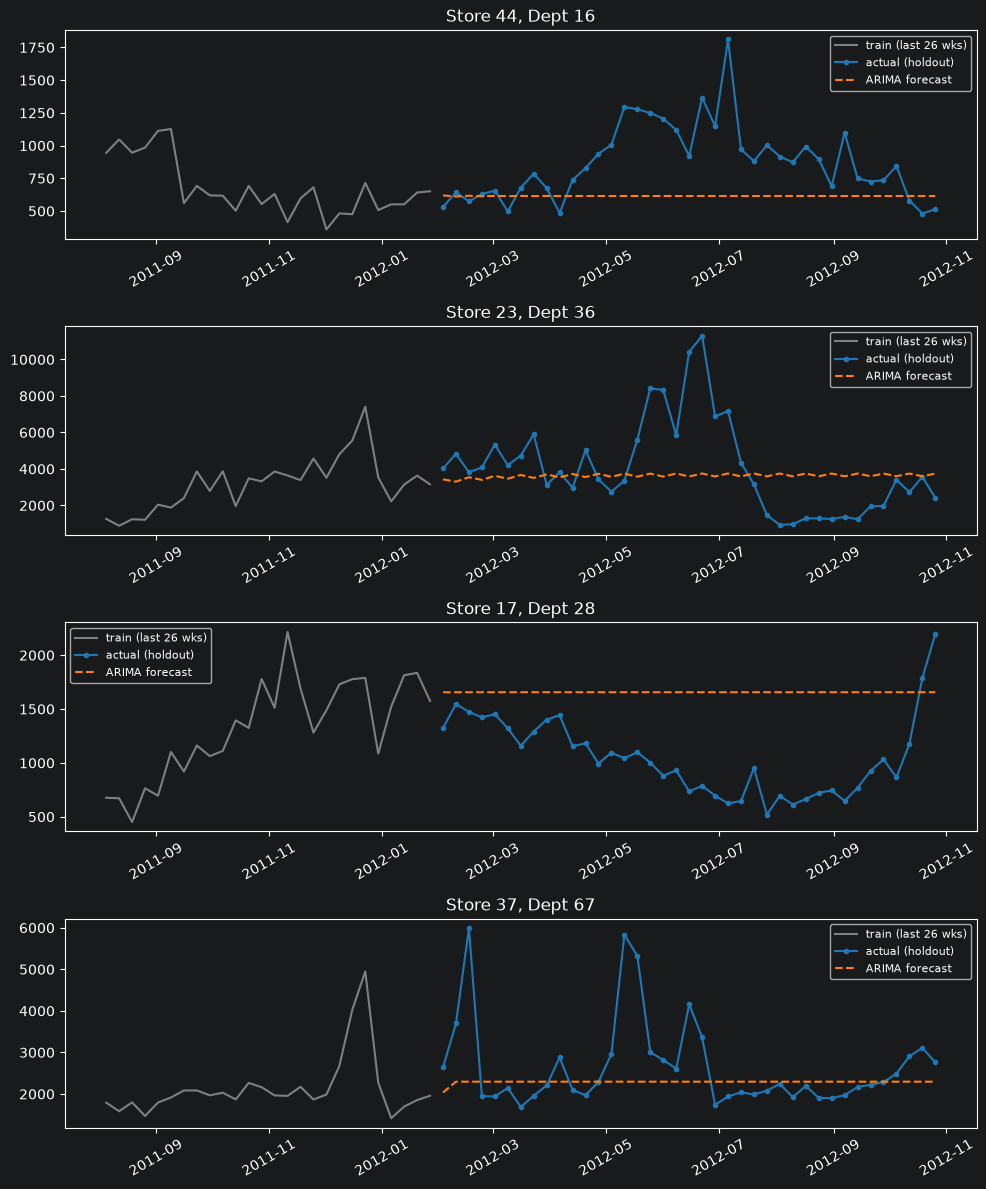

In [11]:
sample_keys = list(example_forecasts.keys())[:4]

fig, axes = plt.subplots(len(sample_keys), 1, figsize=(10, 3 * len(sample_keys)))
if len(sample_keys) == 1:
    axes = [axes]

for ax, key in zip(axes, sample_keys):
    d = example_forecasts[key]
    ax.plot(d["train_dates"], d["train_actual"], label="train (last 26 wks)", color="tab:gray")
    ax.plot(d["dates"], d["actual"], label="actual (holdout)", color="tab:blue", marker="o", markersize=3)
    ax.plot(d["dates"], d["forecast"], label="ARIMA forecast", color="tab:orange", linestyle="--")
    ax.set_title(f"Store {key[0]}, Dept {key[1]}")
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()